In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.metrics import mean_squared_error, mean_absolute_error
from scipy.sparse.linalg import svds

In [32]:
ratings = pd.read_csv('ratings.csv')
movies = pd.read_csv('movies.csv')

ratings.head()
movies.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [33]:
df = pd.merge(ratings, movies, on='movieId')
df.head()

,userId,movieId,rating,timestamp,title,genres
0,1,1,4.0,964982703,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,1,3,4.0,964981247,Grumpier Old Men (1995),Comedy|Romance
2,1,6,4.0,964982224,Heat (1995),Action|Crime|Thriller
3,1,47,5.0,964983815,Seven (a.k.a. Se7en) (1995),Mystery|Thriller
4,1,50,5.0,964982931,"Usual Suspects, The (1995)",Crime|Mystery|Thriller


In [34]:
user_item_matrix = df.pivot_table(
    index='userId',
    columns='title',
    values='rating',
    aggfunc='mean'   
).fillna(0)

user_item_matrix.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.0,0.0
2,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [35]:
user_means = np.mean(user_item_matrix, axis=1)
matrix_demeaned = user_item_matrix.sub(user_means, axis=0)

In [36]:
matrix_demeaned = matrix_demeaned.astype(float)
matrix_demeaned_np = matrix_demeaned.values

k = 100
U, sigma, Vt = svds(matrix_demeaned_np, k=k)
sigma = np.diag(sigma)

In [37]:
reconstructed = np.dot(np.dot(U, sigma), Vt) + user_means.values.reshape(-1, 1)

reconstructed_df = pd.DataFrame(reconstructed,
                                index=user_item_matrix.index,
                                columns=user_item_matrix.columns)

In [38]:
predicted_ratings = reconstructed_df
predicted_ratings.head()

title,'71 (2014),'Hellboy': The Seeds of Creation (2004),'Round Midnight (1986),'Salem's Lot (2004),'Til There Was You (1997),'Tis the Season for Love (2015),"'burbs, The (1989)",'night Mother (1986),(500) Days of Summer (2009),*batteries not included (1987),...,Zulu (2013),[REC] (2007),[REC]² (2009),[REC]³ 3 Génesis (2012),anohana: The Flower We Saw That Day - The Movie (2013),eXistenZ (1999),xXx (2002),xXx: State of the Union (2005),¡Three Amigos! (1986),À nous la liberté (Freedom for Us) (1931)
userId,,,,,,,,,,,,,,,,,,,,,
1,-0.009537,0.241969,0.118689,-0.026377,-0.077345,0.034683,-0.213808,-0.000791,-0.305075,0.127868,...,0.010913,0.023539,0.102375,0.001051,0.101566,-0.389737,-0.149117,0.084324,2.984897,0.084813
2,-0.022257,0.010443,0.006191,-0.008137,-0.012018,-0.005470,0.025454,0.008168,0.246196,0.011745,...,0.005197,-0.030479,-0.012796,-0.034919,0.028342,0.026387,-0.070728,0.001984,0.173782,0.001160
3,0.022382,0.030348,0.041593,0.017206,0.011986,0.009300,0.084125,-0.001588,-0.026017,-0.014662,...,0.009291,0.042664,0.021876,0.023895,0.009386,0.007682,-0.056346,0.026647,0.095766,0.016950
4,0.008815,-0.187725,-0.141656,0.000038,0.139078,-0.029765,-0.370628,0.005432,-0.168585,-0.032854,...,0.003514,-0.435752,-0.339072,-0.045143,-0.031472,0.296685,-0.344663,0.072708,0.638448,0.004478
5,0.008437,-0.012832,0.026115,0.015720,-0.008014,0.011908,0.060525,0.001970,-0.113634,-0.028465,...,0.001557,0.063313,-0.004083,-0.004991,0.004164,-0.073551,-0.024529,0.025653,-0.035159,0.003869


In [39]:
def recommend_movies(user_id, n=10):
    user_row = reconstructed_df.loc[user_id]
    already_rated = user_item_matrix.loc[user_id]

    recommendations = user_row[already_rated == 0]
    recommendations = recommendations.sort_values(ascending=False)

    return recommendations.head(n)

recommend_movies(1)

title
Bill & Ted's Excellent Adventure (1989)                                        2.041374
Chasing Amy (1997)                                                             1.999966
Dr. Strangelove or: How I Learned to Stop Worrying and Love the Bomb (1964)    1.998909
Aliens (1986)                                                                  1.971350
Firm, The (1993)                                                               1.956770
Ice Age (2002)                                                                 1.920508
Casino (1995)                                                                  1.808732
Free Willy (1993)                                                              1.691971
Rain Man (1988)                                                                1.681786
Bug's Life, A (1998)                                                           1.642099
Name: 1, dtype: float64

In [40]:
actual = user_item_matrix.values.flatten()
predicted = reconstructed_df.values.flatten()

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("RMSE:", rmse)
print("MAE:", mae)

RMSE: 0.2518773058316533
MAE: 0.08355301009956986


In [41]:
mask = user_item_matrix.values != 0

actual = user_item_matrix.values[mask]
predicted = reconstructed_df.values[mask]

rmse = np.sqrt(mean_squared_error(actual, predicted))
mae = mean_absolute_error(actual, predicted)

print("Corrected RMSE:", rmse)
print("Corrected MAE:", mae)

Corrected RMSE: 1.581562283273048
Corrected MAE: 1.0775462615810512


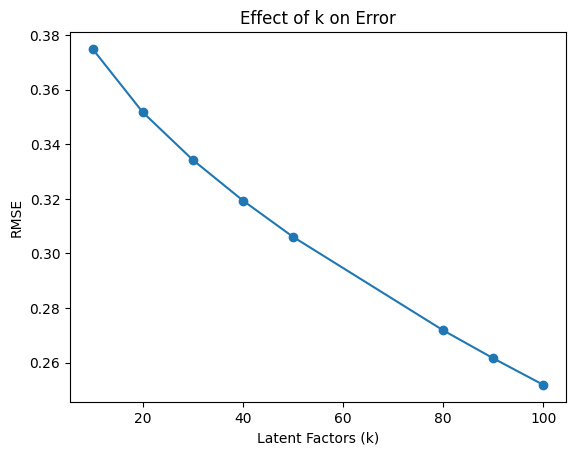

k = 10, RMSE = 0.37487897029506523
k = 20, RMSE = 0.35172538814821985
k = 30, RMSE = 0.33425893984321065
k = 40, RMSE = 0.3193890249913692
k = 50, RMSE = 0.30609444006346365
k = 80, RMSE = 0.27183784565318564
k = 90, RMSE = 0.2615938047144091
k = 100, RMSE = 0.25187730583165324


In [42]:
ks = [10, 20, 30, 40, 50, 80, 90, 100]
rmse_list = []

for k in ks:
    U, sigma, Vt = svds(matrix_demeaned_np, k=k)
    sigma = np.diag(sigma)

    recon = np.dot(np.dot(U, sigma), Vt) + user_means.values.reshape(-1, 1)

    rmse_k = np.sqrt(mean_squared_error(user_item_matrix.values.flatten(),
                                        recon.flatten()))
    rmse_list.append(rmse_k)

plt.figure()
plt.plot(ks, rmse_list, marker='o')
plt.xlabel("Latent Factors (k)")
plt.ylabel("RMSE")
plt.title("Effect of k on Error")
plt.show()

for k, error in zip(ks, rmse_list):
    print(f"k = {k}, RMSE = {error}")

In [43]:
best_k = ks[np.argmin(rmse_list)]
print("Best k (lowest RMSE):", best_k)

Best k (lowest RMSE): 100


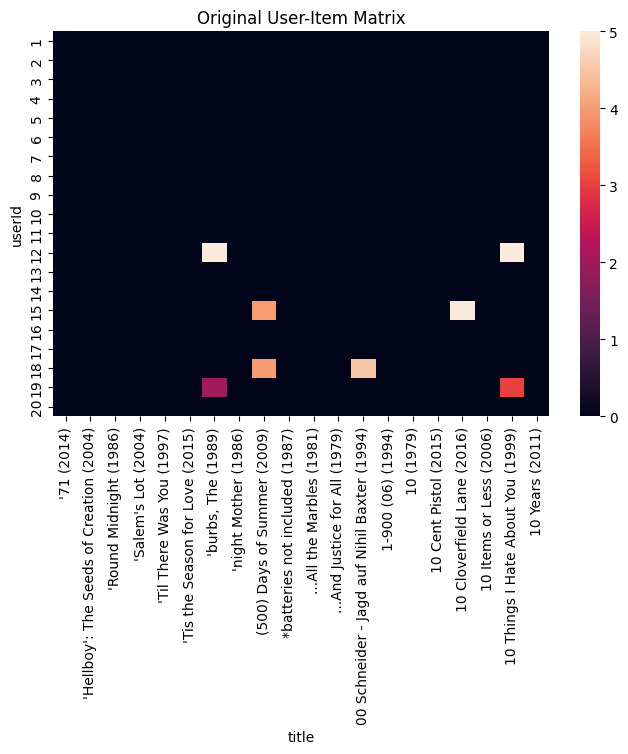

In [44]:
plt.figure(figsize=(8,5))
sns.heatmap(user_item_matrix.iloc[:20, :20])
plt.title("Original User-Item Matrix")
plt.show()

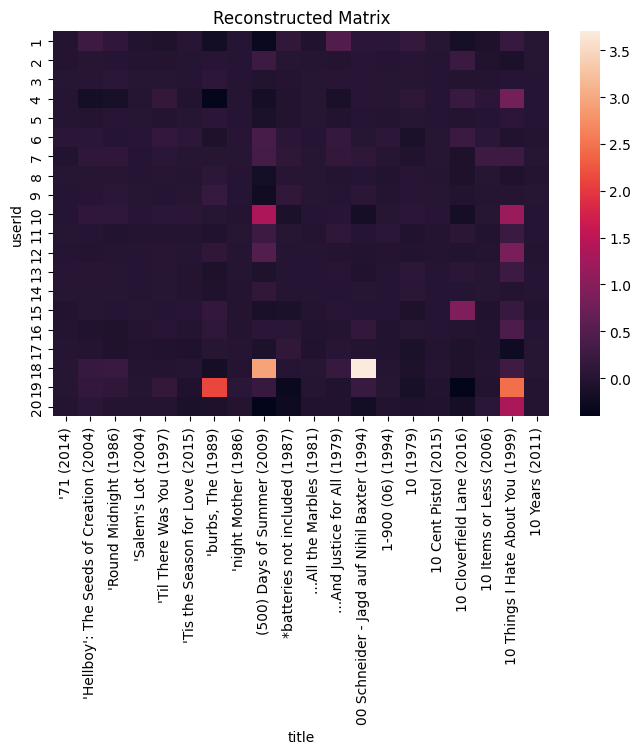

In [45]:
plt.figure(figsize=(8,5))
sns.heatmap(reconstructed_df.iloc[:20, :20])
plt.title("Reconstructed Matrix")
plt.show()

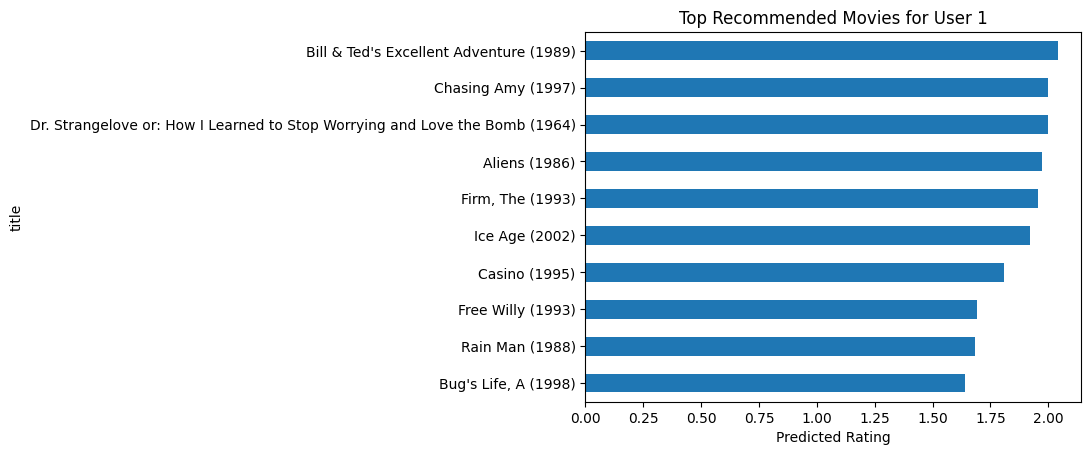

In [46]:
top_movies = recommend_movies(1, 10)

top_movies.sort_values().plot(kind='barh')
plt.title("Top Recommended Movies for User 1")
plt.xlabel("Predicted Rating")
plt.show()

In [47]:
ks = [20, 25, 30]
rmse_list = []

for k in ks:
    U, sigma, Vt = svds(matrix_demeaned_np, k=k)
    sigma = np.diag(sigma)

    recon = np.dot(np.dot(U, sigma), Vt) + user_means.values.reshape(-1, 1)
    recon = np.clip(recon, 1, 5)

    mask = user_item_matrix.values != 0

    rmse_k = np.sqrt(mean_squared_error(
        user_item_matrix.values[mask],
        recon[mask]
    ))

    rmse_list.append(rmse_k)
    print(f"k = {k}, RMSE = {rmse_k}")

k = 20, RMSE = 2.1050891055213787
k = 25, RMSE = 2.0457228132350593
k = 30, RMSE = 1.9917228564873832


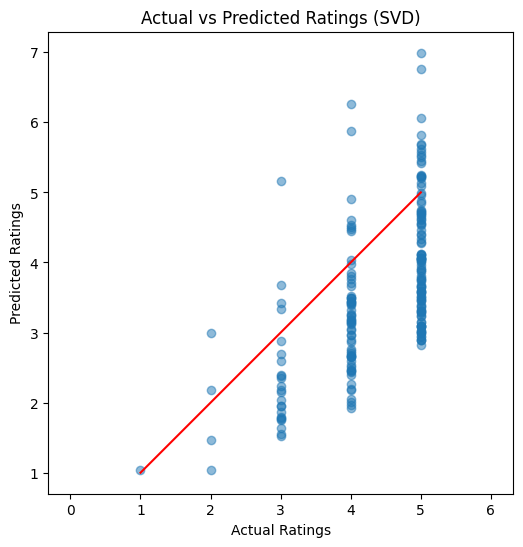

In [48]:
matrix = user_item_matrix.values  # remove /5 scaling

mask = matrix > 0

actual = matrix[mask]
pred = reconstructed[mask]

plt.figure(figsize=(6,6))

plt.scatter(actual[:200], pred[:200], alpha=0.5)

plt.plot([1, 5], [1, 5], color='red')

plt.xlabel("Actual Ratings")
plt.ylabel("Predicted Ratings")
plt.title("Actual vs Predicted Ratings (SVD)")

plt.axis("equal")

plt.show()